# **决策树**

## **基本概念**

一种树形结构,根据条件来判断特征,每个分支代表一个判断结果,每个叶子节点代表一种分类结果.

```mermaid
graph TD
    Root["特征<=阈值"]
    Root -->|是| Left["A"]
    Root -->|否| Right["B"]
    Left --> LL["C"]
    Left --> LR["D"]
    Right --> RL["E"]
    Right --> RR["F"]
```

**分类树**:用于解决分类问题(预测离散类别),如判断邮件是"垃圾邮件"还是"正常邮件".叶节点输出的是类别标签.

**回归树**:用于解决回归问题(预测连续数值),如预测房屋价格.叶节点输出的是该区域内所有样本目标值的平均值(或中位数).

构建一棵决策树,需要解决三个核心问题:
1. 如何选择最优特征进行分裂,也就是特征(节点)的前后顺序如何界定?(信息增益)
2. 如何防止树过于复杂?(剪枝)
3. 何时停止分裂(即构建叶节点)?(停止条件)

## **信息熵**

### **信息熵**

**信息熵**: 衡量数据集的**不确定性**,熵值**越大**,数据集的越混乱,不确定性**越高**.

$$H(x) = - \sum_{i=0}^n p_{x_i} \log_2 p_{x_i}$$

- $H(x)$: 数据集$x$的信息熵
- $n$: 数据集$x$的类别(标签)数量
- $p_{x_i}$: 数据集$x$中第$i$个类别(标签)的概率


> 举个例子:
>
>1.数据α: ABCDEFGH
>
>2.数据β: AAAABBCD
>
>计算数据α的信息熵:因为数据α中有8种不同字符(类别),所以$n=8$,其中A,B,C,D,E,F,G,H出现的概率为$p_{x_i}=\frac{1}{8}$,根据公式计算信息熵为:
>
>$H(x) = - \sum_{i=0}^n p_{x_i} \log_2 p_{x_i} = - (\frac{1}{8} \log_2 \frac{1}{8} + \frac{1}{8} \log_2 \frac{1}{8} + \frac{1}{8} \log_2 \frac{1}{8} + \frac{1}{8} \log_2 \frac{1}{8} + \frac{1}{8} \log_2 \frac{1}{8} + \frac{1}{8} \log_2 \frac{1}{8} + \frac{1}{8} \log_2 \frac{1}{8} + \frac{1}{8} \log_2 \frac{1}{8}) = 3.0$
>
>计算数据β的信息熵:因为数据β中有4种不同字符(类别),所以$n=4$,其中A,B,C,D出现的概率分别为$p_{A}=\frac{1}{2}$,$p_{B}=\frac{1}{4}$,$p_{C}=\frac{1}{8}$,$p_{D}=\frac{1}{8}$,根据公式计算信息熵为:
>
>$H(x) = - \sum_{i=0}^n p_{x_i} \log_2 p_{x_i} = - (\frac{1}{2} \log_2 \frac{1}{2} + \frac{1}{4} \log_2 \frac{1}{4} + \frac{1}{8} \log_2 \frac{1}{8} + \frac{1}{8} \log_2 \frac{1}{8}) = 1.75$


### **信息增益**

#### **条件熵**

**条件熵**: 在已知某些信息后,不确定性的剩余量

**信息熵($H(Y)$)**:是衡量一个随机变量$Y$的**不确定性**,数值越大,不确定性越高.

**条件熵($H(Y|X)$)**:是在已知变量$X$的条件下,变量$Y$的不确定性还剩下多少.

>举个例子:
>
>熵($H(Y)$): 你完全不知道天气,猜明天是否会下雨.
>
>条件熵($H(Y|X)$): 我告诉你"今天的云量"（比如是"多云"）,你在这个额外信息下,再去猜"明天是否下雨"的平均难度.显然,这个难度应该比完全不知道时要低.

**一句话记住它**：条件熵就是"知道了一些线索(X)之后，"猜中答案(Y)的平均难度",这个难度越低,说明线索越有用.


**条件熵公式**:

$$H(Y|X) = \sum_{x \in X} P(x) H(Y|x)$$

- $x \in X$: 特征$X$的所有可能取值.
- $P(x)$: 特征$X$取值为$x$的概率.
- $H(Y|x)$: 特征$X$取值为$x$时,目标$Y$的熵.

#### **信息增益**

**信息增益**:用分裂前的熵减去分裂后各子节点熵的加权平均.信息增益越大,意味着使用该特征分割后,不确定性降低得越多.

信息增益 = 熵 - 条件熵

$$g(Y,X) = H(Y) - H(Y|X)$$


>举个例子
>
>|特征a|标签值|
>|--|--|
>|α|A|
>|α|A|
>|β|B|
>|α|A|
>|β|B|
>|α|B|
>
>已知6个样本,根据特征a
>
>α对应的标签值为AAAB
>
>β对应的标签值为BB
>
>根据信息增益公式,计算特征A的信息增益
>
>**步骤1.计算信息熵**
>
>信息熵=$- \sum_{i=0}^n p_{x_i} \log_2 p_{x_i}$=A的信息熵+B的信息熵 = $-(\frac{1}{2}*\log_2(\frac{1}{2})+\frac{1}{2}*\log_2(\frac{1}{2}))$ = 1
>
>**步骤2.计算条件熵**      
>
>α的条件熵=$- \sum_{i=0}^n p_{x_i} \log_2 p_{x_i}$=AAAB的信息熵 = $-(\frac{1}{4}*\log_2(\frac{1}{4})+\frac{3}{4}*\log_2(\frac{3}{4}))$ = 0.81
>
>β的条件熵=$- \sum_{i=0}^n p_{x_i} \log_2 p_{x_i}$=BB的信息熵 = $-(\frac{2}{2}*\log_2(\frac{2}{2}))$ = 0
>
>条件熵=$\sum_{i=0}^n p_{x_i} H(Y|X=x_i)$=α占比 * α的条件熵+β占比 * β的条件熵 = $(\frac{4}{6}*0.81+\frac{2}{6}*0)$ = 0.54
>
>**步骤3.计算信息增益**
>
>信息增益=$H(Y)-H(Y|X)$=1-0.54 = 0.46


#### **ID3决策树**

优先参考信息增益大的特征,充当节点.

**特点**:
- ID3是能对离散属性的数据集构成决策树;
- 倾向于选择值较多的属性.


>举个例子
>
>已知某一个论坛的客户流失数据,考察**性别**和**活跃度**,哪一个特征的流失率影响最大
>
>||流失|未流失|汇总|
>|--|--|--|--|
>|人数汇总|5|10|15|
>|男|3|5|8|
>|女|2|5|7|
>|高活跃度|0|6|6|
>|中活跃度|1|4|5|
>|低活跃度|4|0|4|
>



>思路:分类别计算**性别**,**活跃度**的信息增益,谁大谁作为根节点.
>
>**步骤1.计算信息熵**
>
>**信息熵**=$-(\frac{5}{15}log_2\frac{5}{15}+\frac{10}{15}log_2\frac{10}{15})=0.9183$
>
>**步骤2.计算条件熵**
>
>**性别的条件熵**=男的占比 * 男的条件熵 + 女的占比 * 女的条件熵 = $\frac{8}{15}*(-(\frac{3}{8}log_2\frac{3}{8}+\frac{5}{8}log_2\frac{5}{8}))+\frac{7}{15}*(-(\frac{2}{7}log_2\frac{2}{7}+\frac{5}{7}log_2\frac{5}{7})) = 0.9118$
>
>****
>
>**活跃度的条件熵**=高活跃度占比 * 高活跃度条件熵 + 中活跃度占比 * 中活跃度条件熵 + 低活跃度占比 * 低活跃度条件熵 = $\frac{6}{15}*(-(\frac{0}{6}log_2\frac{0}{6}+\frac{6}{6}log_2\frac{6}{6}))+\frac{5}{15}*(-(\frac{1}{5}log_2\frac{1}{5}+\frac{4}{5}log_2\frac{4}{5}))+\frac{4}{15}*(-(\frac{4}{4}log_2\frac{4}{4}+\frac{0}{4}log_2\frac{0}{4})) = 0.2406$
>
>**步骤3.计算信息增益**
>
>**性别**的信息增益=信息熵-性别的条件熵=$0.9183-0.9118=0.0065$
>
>****
>
>**活跃度**的信息增益=信息熵-活跃度的条件熵=$0.9183-0.2406=0.6777$
>
>经过比较,**活跃度**的信息增益更大,因此**活跃度**作为根节点.
>
>
>
>
>

### **信息增益率C4.5**

**特点**:
- 缓解了ID3对值较多的属性的偏好.
- 对连续属性的数据集也能构成决策树.增加了对缺失值的处理方法.
- 只适用于能驻留内存的数据集,不能处理非常大的数据集.

#### **特征熵**

**特征熵**: 特征的信息熵.公式和信息熵相同.计算**标签**列叫做信息熵,计算**特征**列叫做特征熵.

#### **特征增益率**

**特征增益率**: $$特征增益率 = \frac{信息增益}{特征熵}$$

>举个例子
>|特征b|特征a|标签值|
>|--|--|--|
>|1|α|A|
>|2|α|A|
>|3|β|B|
>|4|α|A|
>|5|β|B|
>|6|α|B|


>计算特征a的增益率:
>
>**信息熵** $= -\left(\frac{3}{6}\log_2\frac{3}{6} + \frac{3}{6}\log_2\frac{3}{6}\right) = 1$
>
>**特征a的条件熵** $= \frac{4}{6}\times\left[-\left(\frac{3}{4}\log_2\frac{3}{4}+\frac{1}{4}\log_2\frac{1}{4}\right)\right] + \frac{2}{6}\times 0 = 0.5408$
>
>**特征a的特征熵** $= -\left(\frac{4}{6}\log_2\frac{4}{6}+\frac{2}{6}\log_2\frac{2}{6}\right) = 0.9183$
>
>增益率a $= \frac{信息增益a}{特征熵a} = \frac{1-0.5408}{0.9183} = \frac{0.4592}{0.9183} = 0.5$
>
>**特征b的条件熵** $= 6 \times \left(-\frac{1}{6}\times 0\right) = 0$（每个取值只对应1个样本,熵为0）
>
>**特征b的特征熵** $= -\left(\frac{1}{6}\log_2\frac{1}{6}\times 6\right) = \log_2 6 = 2.5850$
>
>增益率b $= \frac{信息增益b}{特征熵b} = \frac{1-0}{2.5850} = 0.3868 \approx 0.39$
>
>特征a的增益率为0.5，特征b的增益率为0.39，所以根据增益率选择特征a作为根节点。
>
>


## **CART决策树**

**CART决策树**:Classification and Regression Tree 分类回归树,既可作为分类,也可作为回归.

**特点**:
- 可以进行**分类**和**回归**,可处理**离散**属性和**连续**属性.
- 采用基尼指数,减小计算量,
- 一定是二叉树

### **CART分类树**

**基尼值Gini(D)**: 从数据集D中,随机抽取两个样本,其类别不相同的概率.基尼值越小,数据集的纯度越高.

$$Gini(D) = 1 - \sum_{k=1}^K p^2_k$$

- $K$: 类别的数量
- $p_k$: 第k类样本所占的比例



>举个例子
>
>在A盒子中有10个颜色相同的小球,在B盒子中有5红色和5个蓝色的小球,盒子C中有5个红色,3个蓝色,2个绿色的小球
>
>盒子A中所有小球的颜色都是相同的,所以拿到颜色相同的概率是1,盒子B中拿到红色的概率是$\frac{1}{2}$,拿到蓝色的概率是$\frac{1}{2}$.盒子C中拿到红色的概率是$\frac{1}{2}$,拿到蓝色的概率是$\frac{3}{10}$,拿到绿色的概率是$\frac{1}{5}$.
>
>$Gini(A) = 1 - 1^2 = 0$
>
>$Gini(B) = 1 - 0.5^2 - 0.5^2 = 0.5$
>
>$Gini(C) = 1-\frac{1}{2}^2-\frac{3}{10}^2-\frac{1}{5}^2 =0.62$
>
>由此可以看出**基尼值越小**,说明样本集的**纯度越高**.基尼值越大,说明样本集的混乱度越大.



**基尼指数Gini_index(D)**:计算每个特征分割后的加权基尼不纯度。选择使基尼指数减少最多（即分割后加权基尼值最小） 的特征

$$Gini_index(D, A) = \sum_{v=1}^V \frac{|D_v|}{|D|} Gini(D_v)$$

- $A$: 特征A的所有可能取值
- $v$: 特征A的某个取值
- $|D_v|$: 特征A取值为v的样本数量
- $|D|$: 数据集D的样本数量
- $Gini(D_v)$: 特征A取值为v的样本子集的基尼值


##### **举个例子**

>假设我们有以下银行贷款申请人的数据：
>
>| 申请ID | 年龄 | 有工作 | 有房产 | 年收入(万) | 信用评级 | 是否批准贷款 |
>|--------|------|--------|--------|------------|----------|--------------|
>| 1 | 青年 | 否 | 否 | 4.5 | 一般 | 否 |
>| 2 | 青年 | 否 | 否 | 3.5 | 好 | 否 |
>| 3 | 青年 | 是 | 否 | 8.0 | 好 | 是 |
>| 4 | 青年 | 是 | 是 | 6.5 | 一般 | 是 |
>| 5 | 青年 | 否 | 否 | 5.0 | 一般 | 否 |
>| 6 | 中年 | 否 | 否 | 6.0 | 一般 | 否 |
>| 7 | 中年 | 否 | 否 | 9.5 | 好 | 否 |
>| 8 | 中年 | 是 | 是 | 12.0 | 好 | 是 |
>| 9 | 中年 | 否 | 是 | 15.0 | 非常好 | 是 |
>| 10 | 中年 | 否 | 是 | 18.0 | 非常好 | 是 |
>| 11 | 老年 | 否 | 是 | 10.0 | 一般 | 是 |
>| 12 | 老年 | 否 | 是 | 8.0 | 好 | 是 |
>| 13 | 老年 | 是 | 否 | 7.0 | 好 | 是 |
>| 14 | 老年 | 是 | 否 | 7.5 | 非常好 | 是 |
>| 15 | 老年 | 否 | 否 | 5.0 | 一般 | 否 |
>
>**目标**：根据这些特征预测是否批准贷款
>
>---
>
>## **CART分类树的构建过程**
>
>### **步骤1：计算数据集的基尼值**
>CART分类树使用**基尼值**作为分裂标准
>
>**基尼值公式**：
>$Gini(D) = 1 - \sum_{k=1}^{K} p_k^2$
>
>其中 $p_k$ 是第k类样本的比例
>
>对于我们的数据集：
>- 批准贷款（是）：9个样本
>- 拒绝贷款（否）：6个样本
>- 总样本数：15
>
>$Gini(D) = 1 - \left(\frac{9}{15}\right)^2 - \left(\frac{6}{15}\right)^2 = 1 - 0.36 - 0.16 = 0.48$
>
>
>---
>
>### **步骤2：计算每个特征的基尼指数**
>
>#### **特征1：年龄**
>年龄有3个取值：青年、中年、老年。CART是二叉树，需要把多分类特征拆成多个二元分裂：
>
>**1. 分裂为{青年}和{中年,老年}**
>- D1(青年)：5个样本 (是:2, 否:3)，Gini(D1)=1-(2/5)²-(3/5)²=0.48
>- D2(中年,老年)：10个样本 (是:7, 否:3)，Gini(D2)=1-(7/10)²-(3/10)²=0.42
>- **加权基尼指数** = (5/15)×0.48 + (10/15)×0.42 = 0.44
>
>**2. 分裂为{中年}和{青年,老年}**
>- D1(中年)：5个样本 (是:3, 否:2)，Gini(D1)=0.48
>- D2(青年,老年)：10个样本 (是:6, 否:4)，Gini(D2)=1-(6/10)²-(4/10)²=0.48
>- **加权基尼指数** = (5/15)×0.48 + (10/15)×0.48 = 0.48
>
>**3. 分裂为{老年}和{青年,中年}**
>- D1(老年)：5个样本 (是:4, 否:1)，Gini(D1)=1-(4/5)²-(1/5)²=0.32
>- D2(青年,中年)：10个样本 (是:5, 否:5)，Gini(D2)=0.5
>- **加权基尼指数** = (5/15)×0.32 + (10/15)×0.5 = 0.44
>
>**年龄的最小基尼指数**：0.44
>
>---
>
>#### **特征2：有工作（二元特征）**
>- D1(有工作=是)：5个样本 (是:5, 否:0)，Gini(D1)=0
>- D2(有工作=否)：10个样本 (是:4, 否:6)，Gini(D2)=1-(4/10)²-(6/10)²=0.48
>- **加权基尼指数** = (5/15)×0 + (10/15)×0.48 = 0.32
>
>---
>
>#### **特征3：有房产（二元特征）**
>- D1(有房产=是)：6个样本 (是:6, 否:0)，Gini(D1)=0
>- D2(有房产=否)：9个样本 (是:3, 否:6)，Gini(D2)=1-(3/9)²-(6/9)²≈0.4444
>- **加权基尼指数** = (6/15)×0 + (9/15)×0.4444 = 0.2667
>
>---
>
>#### **特征4：信用评级**
>信用评级有3个取值：一般、好、非常好，同样做二元化：
>
>**1. 分裂为{一般}和{好,非常好}**
>- D1(一般)：6个样本 (是:2, 否:4)，Gini(D1)=1-(2/6)²-(4/6)²≈0.4444
>- D2(好,非常好)：9个样本 (是:7, 否:2)，Gini(D2)=1-(7/9)²-(2/9)²≈0.3457
>- **加权基尼指数** = (6/15)×0.4444 + (9/15)×0.3457 ≈ 0.3852
>
>**2. 分裂为{非常好}和{一般,好}**
>- D1(非常好)：3个样本 (是:3, 否:0)，Gini(D1)=0
>- D2(一般,好)：12个样本 (是:7, 否:5)，Gini(D2)=1-(7/12)²-(5/12)²≈0.4861
>- **加权基尼指数** = (3/15)×0 + (12/15)×0.4861 ≈ 0.3889
>
>**信用评级的最小基尼指数**：0.3852
>
>---
>
>#### **特征5：年收入（连续特征）**
>对连续特征，需要找到最佳分裂点。计算过程：
>1. 将年收入排序：3.5, 4.5, 5.0, 5.0, 6.0, 6.5, 7.0, 7.5, 8.0, 8.0, 9.5, 10.0, 12.0, 15.0, 18.0
>2. 取相邻值的均值作为候选分裂点
>3. 计算每个分裂点的基尼指数
>
>例如分裂点为6.25（介于6.0和6.5之间）：
>- D1(≤6.25)：5个样本 (是:0, 否:5)，Gini=0
>- D2(>6.25)：10个样本 (是:9, 否:1)，Gini=1-(9/10)²-(1/10)²=0.18
>- **加权基尼指数** = (5/15)×0 + (10/15)×0.18 = 0.12
>
>其他候选分裂点（如5.5、8.25、9.75等）的加权基尼指数都大于0.12，
>因此**年收入的最佳加权基尼指数为0.12**。
>
>---
>
>### **步骤3：选择最佳分裂特征**
>比较各特征的最小加权基尼指数：
>- 年收入：0.12 ✓ **最小**
>- 有房产：0.2667
>- 有工作：0.32
>- 信用评级：0.3852
>- 年龄：0.44
>
>**选择"年收入"作为根节点**，最佳分裂点为6.25（即"年收入≤6.25万"）。
>
>---
>
>### **步骤4：构建决策树（前两层）**
>
>```
>            [年收入≤6.25?]
>            /           \
>          是             否
>          /               \
>     [全部拒绝]      [有房产?]
>     (5个样本)       /       \
>                   是        否
>                   /          \
>              [全部批准]    [继续分裂]
>              (6个样本)    (4个样本)
>```
>
>根节点左侧5个样本（年收入≤6.25万）全部被拒绝，直接成为叶节点。
>右侧10个样本（年收入>6.25万）中有9个批准、1个拒绝（ID 7），需要继续分裂。
>
>对右侧10个样本继续计算各特征的加权基尼指数，"有房产"和"年龄={中年}"并列最小（均为0.15），这里选择"有房产"：
>- 有房产=是：6个样本全部批准，Gini=0，成为叶节点
>- 有房产=否：4个样本（ID 3、7、13、14），其中3个批准、1个拒绝，继续分裂
>
>### **步骤5：完整决策树**
>
>```
>              [年收入≤6.25?]
>              /           \
>            是             否
>            /               \
>       [全部拒绝]        [有房产?]
>       (5个样本)         /       \
>                       是        否
>                       /          \
>                  [全部批准]   [有工作?]
>                  (6个样本)    /       \
>                             是         否
>                             /           \
>                        [全部批准]   [全部拒绝]
>                        (3个样本)    (1个样本)
>```
>
>最后"有房产=否"的4个样本（ID 3、7、13、14）中，ID 3、13、14有工作且都被批准，
>ID 7没有工作被拒绝，按"有工作"分裂后即可完全分对。
>
>这棵决策树在训练集上可以100%正确分类（教学示例；真实场景中需要配合剪枝防止过拟合）。
>
>---
>
>## **CART分类树的关键特点**
>
>1. **二叉树结构**：每个节点只分裂为两个子节点
>2. **分裂标准**：使用基尼指数，选择基尼指数最小的特征和分裂点
>3. **连续特征处理**：排序后寻找最佳分裂点
>4. **分类特征处理**：将多分类特征转换为多个二元分裂
>5. **剪枝**：防止过拟合（可用代价复杂度剪枝）


##### **泰坦尼克号生存预测_代码演示**

预测值: [0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 0 0 0
 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1
 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0
 0 1 1]
评估报告
               precision    recall  f1-score   support

           0       0.81      0.91      0.86       189
           1       0.66      0.45      0.54        73

    accuracy                           0.78       262
   macro avg       0.74      0.68      0.70       262
weighted avg       0.77      0.78      0.77       262



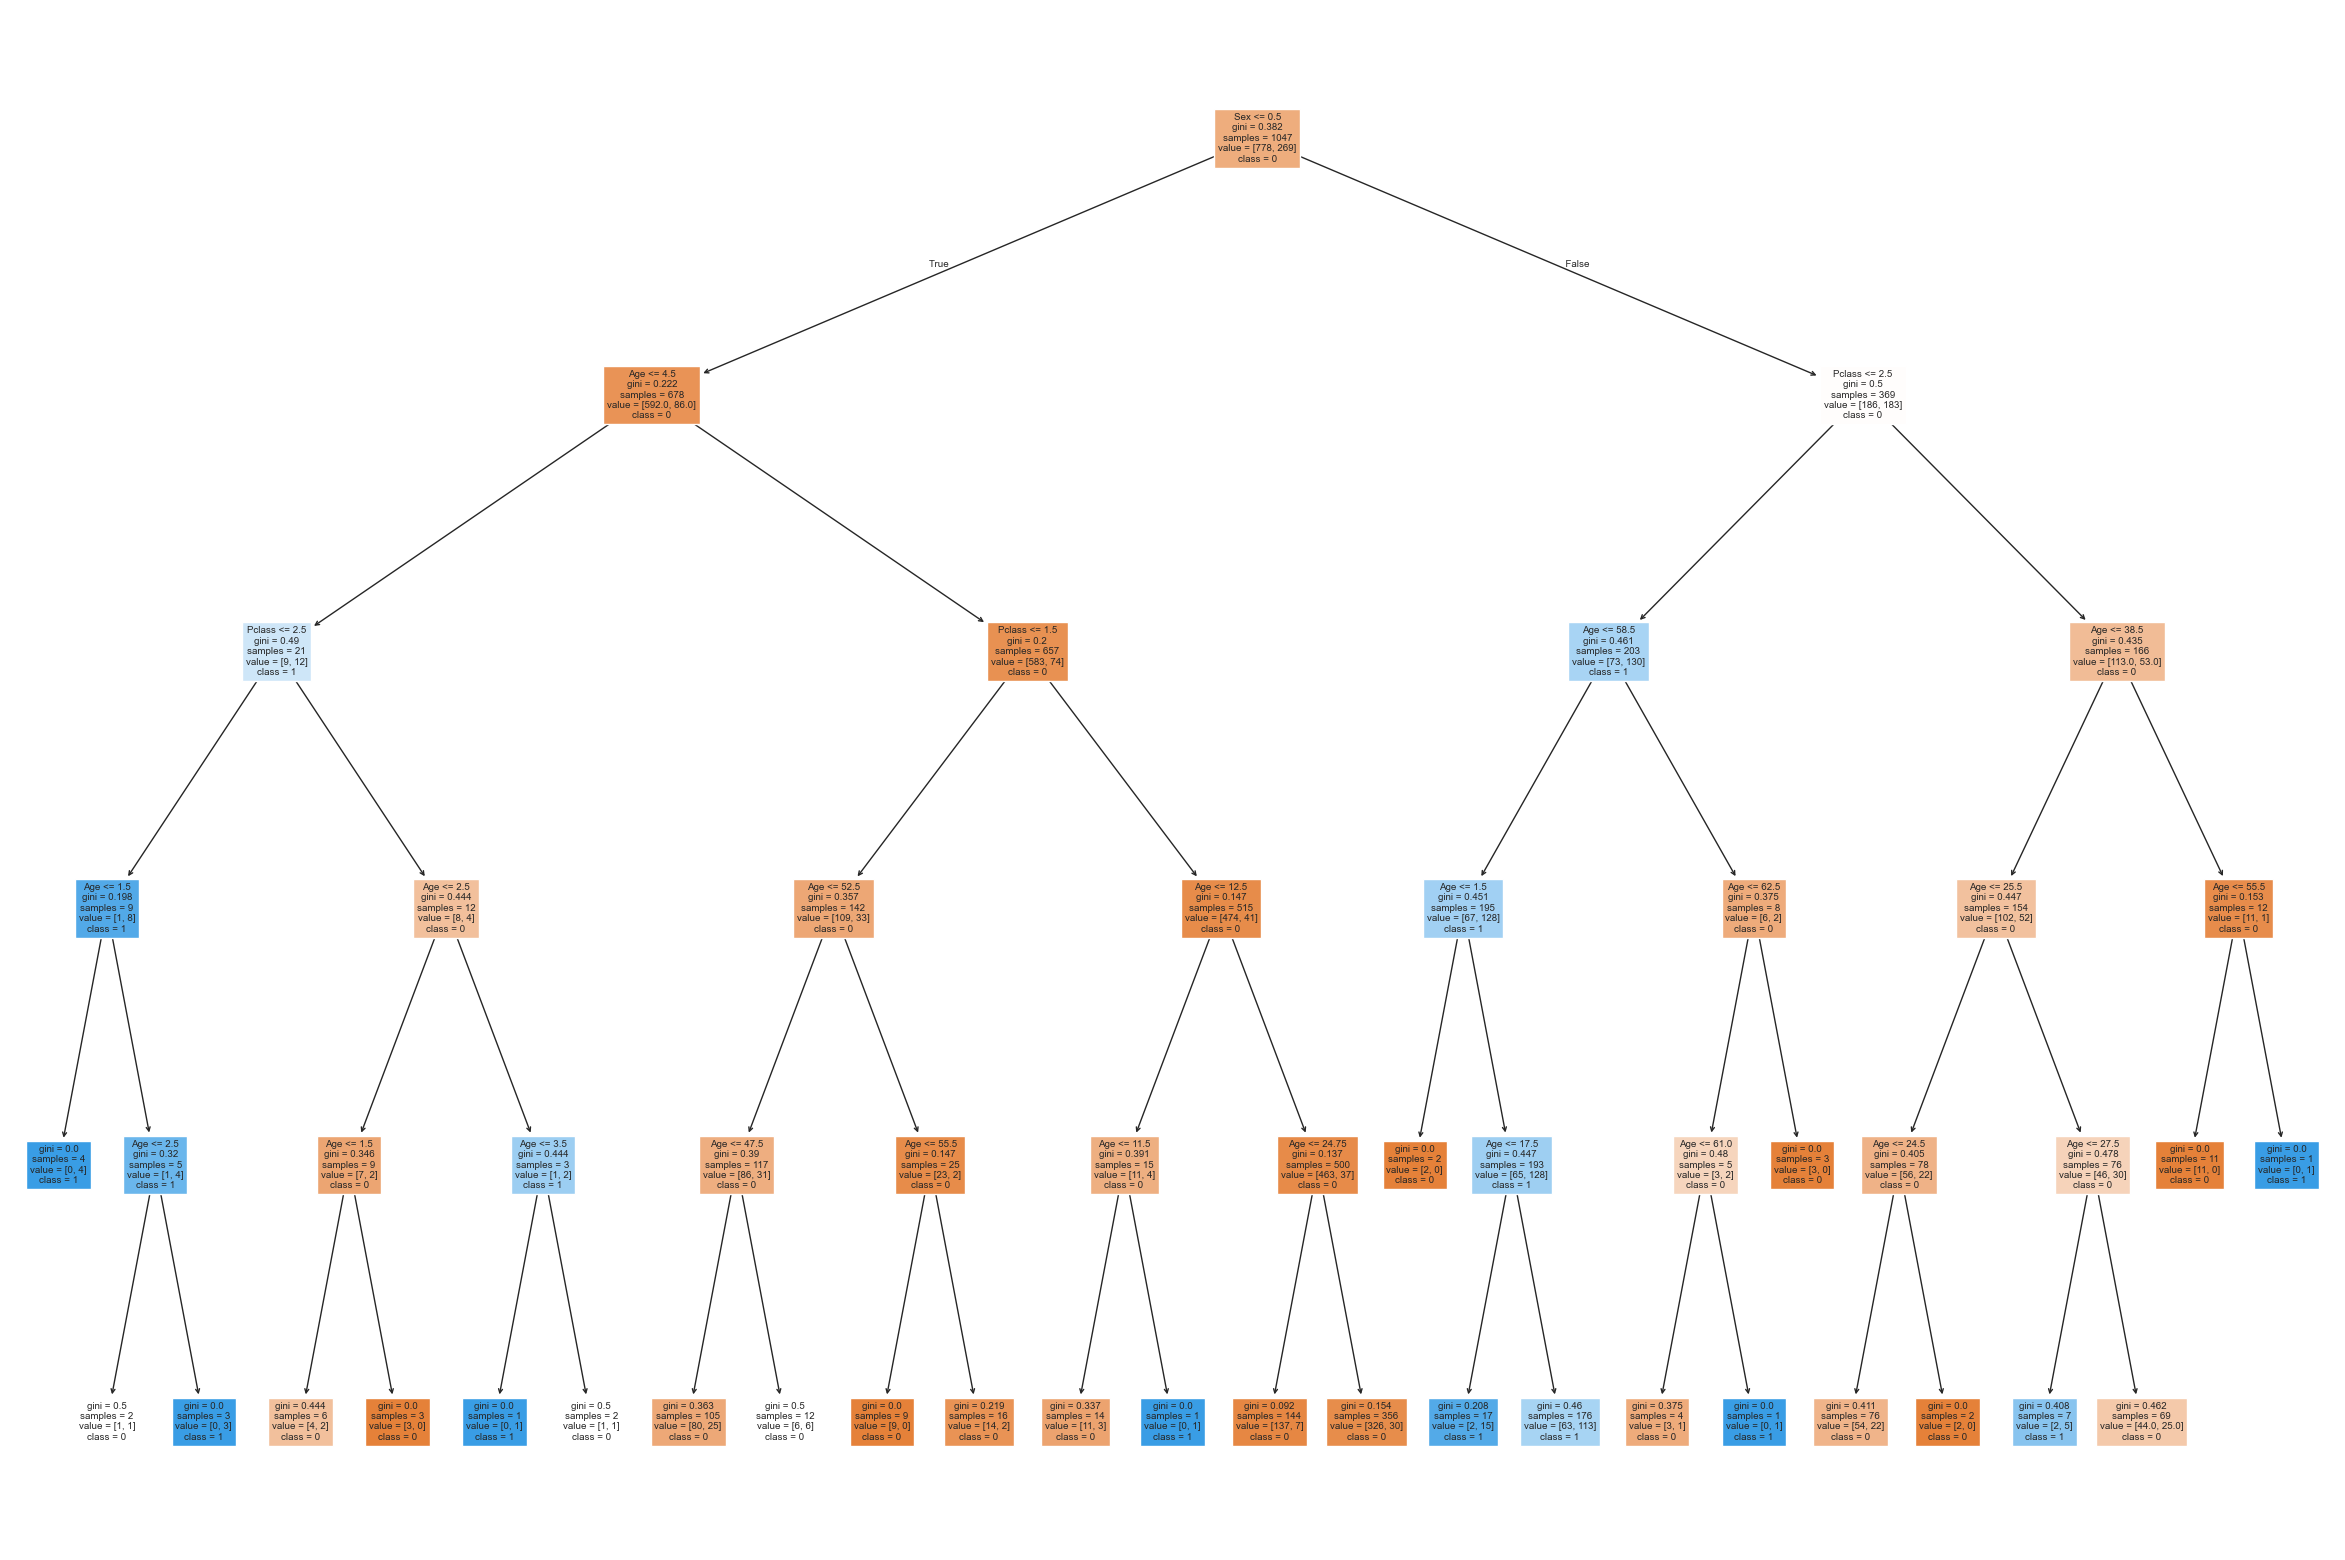

In [6]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('./data/titanic.csv')
# print(data.shape)
# 查看数据信息
# data.info()
# 只选择部分特征
df = data[['Survived','Pclass','Sex','Age']].copy()
if df['Age'].isnull().values.any():
    df['Age'] = df['Age'].fillna(df['Age'].mean())
if df['Sex'].dtype == 'object':
    df['Sex'] = df['Sex'].map({'male':1,'female':0})
x = df[['Pclass','Sex','Age']]
y = df['Survived']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)
print('预测值:',y_pred)

print('评估报告\n',classification_report(y_test,y_pred))
plt.figure(figsize=(30,20))
plot_tree(dt,feature_names=x.columns,class_names=['0','1'],filled=True,max_depth=5)
plt.savefig('./data/dt.png')
plt.show()


### **CART回归树**

**核心思想**: 将特征空间递归地划分为互不重叠的区域,在每个区域内用常数(通常是该区域内样本标签的均值)进行预测.

$$Loss(y,f(x)) = (f(x)-y)^2$$

#### **举个例子**

>## **例子：预测房屋价格**
>
>### **数据集**
>假设我们有10套房屋的数据：
>
>| 房屋ID | 面积(m²) | 房间数 | 房龄(年) | 离地铁距离(km) | 价格(万元) |
>|--------|----------|--------|----------|----------------|------------|
>| 1 | 80 | 2 | 5 | 0.5 | 320 |
>| 2 | 120 | 3 | 8 | 1.2 | 480 |
>| 3 | 100 | 3 | 3 | 0.8 | 420 |
>| 4 | 90 | 2 | 10 | 2.0 | 300 |
>| 5 | 110 | 3 | 5 | 1.0 | 450 |
>| 6 | 130 | 4 | 2 | 0.6 | 580 |
>| 7 | 70 | 1 | 15 | 3.0 | 220 |
>| 8 | 140 | 4 | 1 | 0.4 | 620 |
>| 9 | 85 | 2 | 7 | 1.5 | 310 |
>| 10 | 95 | 2 | 4 | 0.9 | 350 |
>
>**目标**：根据特征预测房屋价格
>
>---
>
>## **CART回归树的构建原理**
>
>### **核心概念：平方误差最小化**
>CART回归树使用**平方误差**作为分裂标准，目标是找到最佳分裂点，使得分裂后两个子集的平方误差之和最小。
>
>**损失函数（平方误差）**：
>$
>L = \sum_{i \in R_1}(y_i - c_1)^2 + \sum_{i \in R_2}(y_i - c_2)^2
>$
>其中：
>- $(R_1, R_2)$：分裂后的两个区域
>- $(c_1, c_2)$：每个区域内样本的均值（预测值）
>
>---
>
>## **构建过程详解**
>
>### **步骤1：初始状态**
>整个数据集（10个样本）：
>- 价格均值：$(\bar{y} = \frac{320+480+420+300+450+580+220+620+310+350}{10} = 405)$
>- 总平方误差：$SSE_{total} = \sum_{i=1}^{10}(y_i - 405)^2$
>  - = $(320-405)^2 + (480-405)^2 + (420-405)^2 + (300-405)^2 + (450-405)^2 + (580-405)^2 + (220-405)^2 + (620-405)^2 + (310-405)^2 + (350-405)^2$
>  - = $7225 + 5625 + 225 + 11025 + 2025 + 30625 + 34225 + 46225 + 9025 + 3025$
>  - = **149250**
>
>### **步骤2：寻找最佳分裂点（以面积为例）**
>
>#### **候选分裂点**：
>对于连续特征，候选分裂点是相邻值的中点：
>面积排序：70, 80, 85, 90, 95, 100, 110, 120, 130, 140
>候选分裂点：75, 82.5, 87.5, 92.5, 97.5, 105, 115, 125, 135
>
>#### **计算分裂点s=97.5（介于95和100之间）**：
>- 左区域R1（面积≤97.5）：样本70, 80, 85, 90, 95
>  - 价格：220, 320, 310, 300, 350
>  - 均值 $(c_1 = \frac{220+320+310+300+350}{5} = 300)$
>  - 平方误差：$(220-300)^2 + (320-300)^2 + (310-300)^2 + (300-300)^2 + (350-300)^2 = 6400+400+100+0+2500 = 9400$
>
>- 右区域R2（面积>97.5）：样本100, 110, 120, 130, 140
>  - 价格：420, 450, 480, 580, 620
>  - 均值 $(c_2 = \frac{420+450+480+580+620}{5} = 510)$
>  - 平方误差：$(420-510)^2 + (450-510)^2 + (480-510)^2 + (580-510)^2 + (620-510)^2 = 8100+3600+900+4900+12100 = 29600$
>
>- **总平方误差** = 9400 + 29600 = 39000
>
>#### **计算分裂点s=87.5（介于85和90之间）**：
>- 左区域R1（面积≤87.5）：样本70, 80, 85
>  - 均值 $(c_1 = \frac{220+320+310}{3} = 283.33)$
>  - 平方误差：$(220-283.33)^2 + (320-283.33)^2 + (310-283.33)^2 = 4011.11 + 1344.44 + 711.11 = 6066.67$
>
>- 右区域R2（面积>87.5）：剩余7个样本（90, 95, 100, 110, 120, 130, 140）
>  - 价格：300, 350, 420, 450, 480, 580, 620
>  - 均值 $(c_2 = \frac{300+350+420+450+480+580+620}{7} = 457.14)$
>  - 平方误差：约 **79742.86**
>
>- **总平方误差** = 6066.67 + 79742.86 = 85809.53
>
>#### **计算分裂点s=105（介于100和110之间）**：
>- 左区域R1（面积≤105）：样本70, 80, 85, 90, 95, 100
>  - 价格：220, 320, 310, 300, 350, 420
>  - 均值 $(c_1 = \frac{220+320+310+300+350+420}{6} = 320)$
>  - 平方误差：$(220-320)^2+(320-320)^2+(310-320)^2+(300-320)^2+(350-320)^2+(420-320)^2 = 10000+0+100+400+2500+10000 = 21400$
> 
>- 右区域R2（面积>105）：样本110, 120, 130, 140
>  - 均值 $(c_2 = \frac{450+480+580+620}{4} = 532.5)$
>  - 平方误差：$6806.25+2756.25+2256.25+7656.25 = 19475$
>
>- **总平方误差** = 21400 + 19475 = 40875
>
>**最佳分裂点**：s=97.5（总平方误差最小：39000）
>
>---
>
>### **步骤3：比较所有特征**
>
>同样方法计算其他特征：
>
>#### **特征2：房间数**（离散值）
>房间数排序：1, 2, 2, 2, 2, 3, 3, 3, 4, 4
>
>候选分裂点：
>1. 房间数≤1 vs >1
>2. 房间数≤2 vs >2
>3. 房间数≤3 vs >3
>
>计算得：
>- 分裂点"房间数≤1 vs >1"：总平方误差=**111088.89**
>- 分裂点"房间数≤2 vs >2"：总平方误差=**39000**
>- 分裂点"房间数≤3 vs >3"：总平方误差=**54187.5**
>
>**最佳**：房间数≤2 vs >2（39000，与面积≤97.5的分区恰好相同）
>
>#### **特征3：房龄**、**特征4：离地铁距离**
>同样计算，各特征的最佳平方误差为：
>- 面积：39000（分裂点≤97.5）
>- 房间数：39000（分裂点≤2）
>- 房龄：54187.5（分裂点≤2.5）
>- 离地铁距离：78666.67（分裂点≤1.35）
>
>**结论**：选择"面积≤97.5"作为第一层分裂（与"房间数≤2"等价）
>
>---
>
>### **步骤4：构建回归树（前两层）**
>
>```
>            [面积≤97.5?]
>            /         \
>          是           否
>          /             \
>     [价格=300]    [房间数≤3?]
>     (5个样本)      /       \
>                  是        否
>                  /          \
>             [价格=450]   [价格=600]
>             (3个样本)    (2个样本)
>```
>
>其中：
>- 叶节点1（面积≤97.5）：预测值300万元（样本：220, 320, 310, 300, 350）
>- 叶节点2（面积>97.5且房间数≤3）：预测值450万元（样本：420, 450, 480）
>- 叶节点3（面积>97.5且房间数>3）：预测值600万元（样本：580, 620）
>
>第二层分裂后的总平方误差：9400 + 1800 + 800 = 12000，比只分一层时（39000）大幅下降。
>
>---
>
>## **CART回归树的特点**
>
>### **1. 预测值计算**
>每个叶节点的预测值是该节点内所有样本的**平均值**
>
>### **2. 分裂标准**
>使用**平方误差最小化**（MSE）：
>$
>\min_{j,s} \left[ \min_{c_1} \sum_{x_i \in R_1(j,s)} (y_i - c_1)^2 + \min_{c_2} \sum_{x_i \in R_2(j,s)} (y_i - c_2)^2 \right]
>$
>其中：
>- $(j)$：特征索引
>- $(s)$：分裂点
>- $(c_1, c_2)$：两个区域的均值
>
>### **3. 与分类树的区别**
>
>| 方面 | CART分类树 | CART回归树 |
>|------|------------|------------|
>| 目标变量 | 离散型 | 连续型 |
>| 分裂标准 | 基尼指数 | 平方误差最小化 |
>| 叶节点值 | 类别（多数表决） | 数值（均值） |
>| 预测输出 | 类别标签 | 连续数值 |
>
>---
>
>
>## **回归树的剪枝**
>
>CART回归树使用**代价复杂度剪枝**（Cost-Complexity Pruning）：
>
>- **目标函数**：
>$
>C_\alpha(T) = \sum_{t=1}^{|T|} N_t \cdot MSE(t) + \alpha|T|
>$
>其中：
>- $(T)$：树的叶节点数
>- $(N_t)$：叶节点t的样本数
>- $(MSE(t))$：叶节点t的均方误差
>- $(\alpha)$：复杂度参数
>
>- **剪枝过程**：
>1. 从底向上，计算每个内部节点剪枝前后的代价复杂度
>2. 选择使代价复杂度减少最小的节点进行剪枝
>3. 重复直到达到最优复杂度
>
>---
>
>## **CART回归树的优缺点**
>
>### **优点：**
>1. **可解释性强**：树结构直观易懂
>2. **处理混合类型特征**：可同时处理数值和类别特征
>3. **不需要特征缩放**：对特征的尺度不敏感
>4. **处理非线性关系**：能捕捉复杂的非线性模式
>
>### **缺点：**
>1. **容易过拟合**：需要剪枝
>2. **不稳定**：数据微小变化可能导致树结构巨变
>3. **预测有偏**：倾向于在边界处产生不连续预测
>
>---
>
>### **实际应用场景**
>
>1. **房价预测**（本例）
>2. **销量预测**
>3. **股票价格预测**
>4. **用户生命周期价值预测**
>5. **医疗费用预测**
>
>通过这个例子，你可以看到CART回归树如何通过递归地选择最佳分裂特征和分裂点来构建预测模型，最终每个叶节点提供一个具体的数值预测。


### **剪枝**

构建的决策树可能会层级很深,容易过拟合,可以通过剪枝防止过拟合.

**特点**:
- 去掉对少数异常样本的特殊处理

- 合并相似的决策路径

- 用更简单的规则近似复杂规则

- 在保持预测能力的前提下降低复杂度

#### **预剪枝(pre-pruning)**

**预剪枝**:在树生长过程中提前停止.在决策树的生成过程中,对每个节点在划分前先进行估计,若当前节点的划分不能带来决策树泛化性能提升,则停止划分,将当前节点标记为叶节点.

**优点**:
- 可以减少过拟合风险
- 简单,计算快

**缺点**:
- 可能欠拟合,可能会"过剪枝",导致模型在训练集上的性能低于未剪枝的决策树

#### **后剪枝(post-pruning)**


**后剪枝**:在树生成完成后,从下往上遍历每个节点,若将该节点转换为叶节点能带来决策树泛化性能提升,则将该节点转换为叶节点.

CART算法使用**代价复杂度剪枝**（Cost-Complexity Pruning）：

$$
C_\alpha(T) = \sum_{t=1}^{|T|} N_t \cdot MSE(t) + \alpha|T|
$$
其中：
- $(T)$：树的叶节点数
-  $(N_t)$：叶节点t的样本数
- $(MSE(t))$：叶节点t的均方误差
- $(\alpha)$：复杂度参数

- **剪枝过程**：
1. 从底向上，计算每个内部节点剪枝前后的代价复杂度
2. 选择使代价复杂度减少最小的节点进行剪枝
3. 重复直到达到最优复杂度